In [19]:
import pandas as pd
import numpy as np
df=pd.read_pickle(f"../df24.pkl")
y=df[['dm']]
X=df.drop(columns=['dm'])

In [20]:
from sklearn.model_selection import train_test_split


In [21]:
X_life=X[['wk_smk',
'wk_alc', 'wk_mvpa_work', 'wk_mvpa_play', 'wk_walk', 'wk_sleep',
'stress', 'wk_break', 'wk_lunch', 'wk_dinner', 'wk_veg1', 'wk_veg2',
'wk_fruit']]

X_demo=X[['sex', 'age', 'edu', 'income', 'job']]

X_lab=X[['chol', 'hdl', 'tg', 'ldl', 'sbp', 'wt', 'ht', 'wc', 'bmi']]


glu=X['glu']
hba1c=X['hba1c']

c:\Users\cmc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\cmc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Test Accuracy: 0.8624277456647399


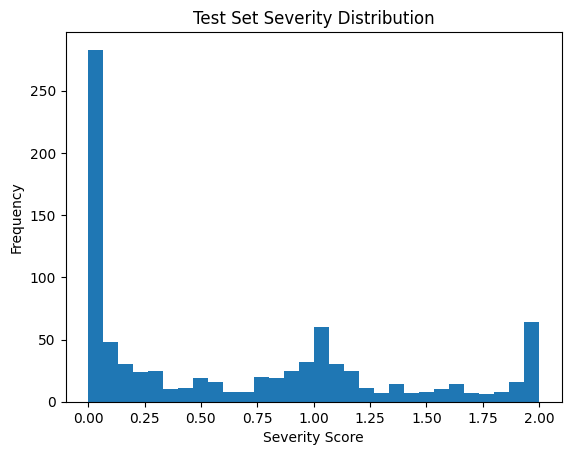

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier


# =========================
# 1. Train / Test split
# =========================

X_life_tr, X_life_te, \
X_demo_tr, X_demo_te, \
X_lab_tr,  X_lab_te,  \
glu_tr, glu_te, \
hba1c_tr, hba1c_te, \
y_tr, y_te = train_test_split(
    X_life, X_demo, X_lab, glu, hba1c, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# =========================
# 2. OOF 생성 (train에서만)
# =========================

n_train = len(y_tr)

z1_oof = np.zeros(n_train)
z2_oof = np.zeros(n_train)
z3_oof = np.zeros(n_train)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in kf.split(X_life_tr):
    
    y_fold_tr = y_tr.iloc[train_idx]
    
    # lifestyle
    model1 = XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        n_estimators=300,
        learning_rate=0.01,
        max_depth=4,
        eval_metric="mlogloss",
        random_state=42
    )
    model1.fit(X_life_tr.iloc[train_idx], y_fold_tr)
    z1_oof[val_idx] = model1.predict_proba(
        X_life_tr.iloc[val_idx]
    ) @ np.array([0,1,2])
    
    # demographic
    model2 = XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        n_estimators=300,
        learning_rate=0.01,
        max_depth=4,
        eval_metric="mlogloss",
        random_state=42
    )
    model2.fit(X_demo_tr.iloc[train_idx], y_fold_tr)
    z2_oof[val_idx] = model2.predict_proba(
        X_demo_tr.iloc[val_idx]
    ) @ np.array([0,1,2])
    
    # laboratory
    model3 = XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        n_estimators=300,
        learning_rate=0.01,
        max_depth=4,
        eval_metric="mlogloss",
        random_state=42
    )
    model3.fit(X_lab_tr.iloc[train_idx], y_fold_tr)
    z3_oof[val_idx] = model3.predict_proba(
        X_lab_tr.iloc[val_idx]
    ) @ np.array([0,1,2])


# =========================
# 3. Meta 모델 학습 (train)
# =========================

meta_train = pd.DataFrame({
    "z1": z1_oof,
    "z2": z2_oof,
    "z3": z3_oof,
    "glu": glu_tr,
    "hba1c": hba1c_tr
})

scaler = StandardScaler()
meta_train_scaled = scaler.fit_transform(meta_train)

meta_model = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=2000
)

meta_model.fit(meta_train_scaled, y_tr)


# =========================
# 4. Test set 예측
# =========================

# block 모델을 train 전체로 다시 학습

final_model1 = XGBClassifier(objective="multi:softprob",
                             num_class=3,
                             n_estimators=300,
                             learning_rate=0.01,
                             max_depth=4,
                             eval_metric="mlogloss",
                             random_state=42)

final_model2 = XGBClassifier(objective="multi:softprob",
                             num_class=3,
                             n_estimators=300,
                             learning_rate=0.01,
                             max_depth=4,
                             eval_metric="mlogloss",
                             random_state=42)

final_model3 = XGBClassifier(objective="multi:softprob",
                             num_class=3,
                             n_estimators=300,
                             learning_rate=0.01,
                             max_depth=4,
                             eval_metric="mlogloss",
                             random_state=42)

final_model1.fit(X_life_tr, y_tr)
final_model2.fit(X_demo_tr, y_tr)
final_model3.fit(X_lab_tr, y_tr)

z1_test = final_model1.predict_proba(X_life_te) @ np.array([0,1,2])
z2_test = final_model2.predict_proba(X_demo_te) @ np.array([0,1,2])
z3_test = final_model3.predict_proba(X_lab_te)  @ np.array([0,1,2])


meta_test = pd.DataFrame({
    "z1": z1_test,
    "z2": z2_test,
    "z3": z3_test,
    "glu": glu_te,
    "hba1c": hba1c_te
})

meta_test_scaled = scaler.transform(meta_test)

y_proba_test = meta_model.predict_proba(meta_test_scaled)

severity_test = y_proba_test @ np.array([0,1,2])

print("Test Accuracy:",
      accuracy_score(y_te,
                     meta_model.predict(meta_test_scaled)))


# =========================
# 5. 히스토그램
# =========================

plt.hist(severity_test, bins=30)
plt.xlabel("Severity Score")
plt.ylabel("Frequency")
plt.title("Test Set Severity Distribution")
plt.show()